In [1]:
import torch
import numpy as np

# creating tensors

In [2]:
# from numpy array
v_np = np.zeros([3,4])
v_tensor = torch.tensor(v_np)
v_tensor

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], dtype=torch.float64)

In [3]:
# create tensor from list
v = torch.tensor([2,3])         # a tensor initialized with a list, int64
v = torch.Tensor([2,3])      # a tensor initialized with a list, float32


In [4]:
# create tensor from random numbers
torch.manual_seed(1)
points=torch.randn(3,2)   # standard normal distribution
print(points)
points.shape

tensor([[ 0.6614,  0.2669],
        [ 0.0617,  0.6213],
        [-0.4519, -0.1661]])


torch.Size([3, 2])

In [5]:
# create by filling with 1 or 0
eye = torch.eye(3)              # Create an identity 3x3 tensor
v = torch.ones(10)              # A tensor of size 10 containing all ones
v = torch.ones(2, 1, 2, 1)      # fill with 1, Size 2x1x2x1
v = torch.ones_like(eye)        # A tensor with same shape as eye. Fill it with 1.
v = torch.zeros(10)             # A tensor of size 10 containing all zeros


In [6]:
# create by arange
v = torch.arange(9)
print(v)
v = v.view(3, 3)
print(v)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])
tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])


In [7]:
v = torch.linspace(1, 10, steps=10) 
print(v)
# Create a Tensor with 10 linear points for (1, 10) inclusively
v = torch.logspace(start=-10, end=10, steps=5) 
# Size 5: 1.0e-10 1.0e-05 1.0e+00, 1.0e+05, 1.0e+10
print(v)

tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])
tensor([1.0000e-10, 1.0000e-05, 1.0000e+00, 1.0000e+05, 1.0000e+10])


In [8]:
c = torch.ByteTensor([0, 1, 1, 0])
print(c)

tensor([0, 1, 1, 0], dtype=torch.uint8)


# tensor operations

#indexing

In [9]:
a=points[:, -1]
print(a)
a.shape

tensor([ 0.2669,  0.6213, -0.1661])


torch.Size([3])

#re-organize: view, cat, stack, gather, squeeze, unsqueeze

In [10]:
v=torch.arange(9)
v=v.view(3,3)
v

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [11]:
y=torch.cat([v,v,v,v],1)   
# concatenation along with 1 (column) dimension or 0 (row) dimension   
#y.shape
y

tensor([[0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2],
        [3, 4, 5, 3, 4, 5, 3, 4, 5, 3, 4, 5],
        [6, 7, 8, 6, 7, 8, 6, 7, 8, 6, 7, 8]])

In [12]:
y=torch.stack((v,v))  # add one more dimension
y.shape

torch.Size([2, 3, 3])

In [13]:
t = torch.tensor([[1, 2], [3, 4]])   
torch.gather(t, 1, torch.tensor([[0, 0], [1, 0]])) # gather along with column (axis 1)

tensor([[1, 1],
        [4, 3]])

In [14]:
t = torch.tensor([[1, 2], [3, 4]])
torch.gather(t, 0, torch.tensor([[0, 0], [1, 0]]))  # gather along with row (axis 0)

tensor([[1, 2],
        [3, 2]])

In [15]:
x = torch.zeros(2, 1, 2, 1, 2)
print("original", x.size())
y = torch.squeeze(x)               # dimensions with size 1 will be removed
print("after squeeze", y.size())

original torch.Size([2, 1, 2, 1, 2])
after squeeze torch.Size([2, 2, 2])


In [16]:
x = torch.tensor([1, 2, 3, 4])
print(x.shape, x)
y=torch.unsqueeze(x, 0) 
# Returns a new tensor with a dimension of size one 
# inserted at the specified position.
print(y.shape, y)
y=torch.unsqueeze(x, 1)
print(y.shape, y)

torch.Size([4]) tensor([1, 2, 3, 4])
torch.Size([1, 4]) tensor([[1, 2, 3, 4]])
torch.Size([4, 1]) tensor([[1],
        [2],
        [3],
        [4]])


In [17]:
# torch.transpose(input, dim0, dim1)
# Returns a tensor that is a transposed version of input.
# The given dimensions dim0 and dim1 are swapped.
x = torch.randn(2,3)
y = torch.transpose(x, 0, 1)
print(x)
print(y)

tensor([[-1.5228,  0.3817, -1.0276],
        [-0.5631, -0.8923, -0.0583]])
tensor([[-1.5228, -0.5631],
        [ 0.3817, -0.8923],
        [-1.0276, -0.0583]])


In [18]:
y=torch.chunk(x,3,1)   # 3 is the number of chunks
y= torch.split(x, [1,2], 1) # [1,2] is the size of each section
y[1]

tensor([[ 0.3817, -1.0276],
        [-0.8923, -0.0583]])

In [19]:
indices = torch.tensor([0, 2])
torch.index_select(x, 1, indices) # select along dimension 1 by indices

tensor([[-1.5228, -1.0276],
        [-0.5631, -0.0583]])

In [20]:
mask = x.ge(0)
print(mask)

tensor([[False,  True, False],
        [False, False, False]])


In [21]:
y=torch.masked_select(x, mask)
print(y.shape, y)

torch.Size([1]) tensor([0.3817])


In [22]:
y=torch.nonzero(v) # return the index for non-zero elements in v
print(y.shape, y)

torch.Size([8, 2]) tensor([[0, 1],
        [0, 2],
        [1, 0],
        [1, 1],
        [1, 2],
        [2, 0],
        [2, 1],
        [2, 2]])


In [23]:
y=torch.take(x, torch.tensor([0, 2, 5]))
print(y)

tensor([-1.5228, -1.0276, -0.0583])


# point-wise operations

In [24]:
y=torch.abs(x)
print(y)

tensor([[1.5228, 0.3817, 1.0276],
        [0.5631, 0.8923, 0.0583]])


In [25]:
x2=torch.randn(2,3)
print(x2)

tensor([[-0.1955, -0.9656,  0.4224],
        [ 0.2673, -0.4212, -0.5107]])


In [26]:
y=torch.add(x,10) # add 10 to all elements
print(y)

tensor([[ 8.4772, 10.3817,  8.9724],
        [ 9.4369,  9.1077,  9.9417]])


In [27]:
y=torch.add(x,10,x2) # x+10*x2
print(y)

tensor([[-3.4779, -9.2747,  3.1965],
        [ 2.1101, -5.1042, -5.1652]])


In [28]:
y=torch.clamp(x2,min=-0.5, max=0.5)
print(y)

tensor([[-0.1955, -0.5000,  0.4224],
        [ 0.2673, -0.4212, -0.5000]])


In [29]:
y=torch.div(x, x2)
y=torch.mul(x,x2)
y=torch.acos(x)
y=torch.ceil(x)
y=torch.pow(x,x2)
y=torch.reciprocal(x)
y=torch.sign(x)
y=torch.sqrt(x)
print(y)

tensor([[   nan, 0.6178,    nan],
        [   nan,    nan,    nan]])


# Reduction operations

In [30]:
v=v.to(torch.float32) # some operations do not support long type, 
v

tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

In [31]:
y=torch.cumprod(v,0) #cummulative product along dimension 0
y=torch.cumsum(v,1)  #cummulative sum along dimension 1
d=torch.dist(v, v+3, p=2)
d=torch.mean(v,0, True) # True keep dimension
d=torch.mean(v) # mean for all elements
d=torch.sum(v,1)
d=torch.median(v,0)
d=torch.mode(v,1) # return mode and index
d=torch.prod(v,0) # product of elements
d=torch.std(v,0)  # standard deviation
d=torch.var(v,0)  # variance
print(d)

tensor([9., 9., 9.])


# Comparison operations

In [32]:
d=torch.eq(x,x2)
d=torch.max(v,0)
d=torch.equal(v,v)
d=torch.ge(x,x2)
d=torch.gt(x,x2)
d=torch.kthvalue(v, 2, 0, True)
d=torch.ne(x,x2)
d=torch.sort(v,0)
d=torch.topk(v,2)
print(d)

torch.return_types.topk(
values=tensor([[2., 1.],
        [5., 4.],
        [8., 7.]]),
indices=tensor([[2, 1],
        [2, 1],
        [2, 1]]))


# Matrix, vector multiplication

In [33]:
d=torch.dot(torch.tensor([1,2]), torch.tensor([3,4]))
mat = torch.randn(2, 4)
vec = torch.tensor([1.,2.,3.,4.])
d = torch.mv(mat, vec)
# Matrix + Matrix X vector
# Size 2
M = torch.randn(2)
mat = torch.randn(2, 3)
vec = torch.randn(3)
d = torch.addmv(M, mat, vec)
# Matrix x Matrix
# Size 2x4
mat1 = torch.randn(2, 3)
mat2 = torch.randn(3, 4)
d = torch.mm(mat1, mat2)

# Matrix + Matrix X Matrix
# Size 3x4
M = torch.randn(3, 4)
mat1 = torch.randn(3, 2)
mat2 = torch.randn(2, 4)
d = torch.addmm(M, mat1, mat2)
# Batch Matrix x Matrix
# Size 10x3x5
batch1 = torch.randn(10, 3, 4)
batch2 = torch.randn(10, 4, 5)
d = torch.bmm(batch1, batch2)
# Batch Matrix + Matrix x Matrix
# Performs a batch matrix-matrix product
# 3x2 + (5x3x4 X 5x4x2 ) -> 5x3x2
M = torch.randn(3, 2)
batch1 = torch.randn(5, 3, 4)
batch2 = torch.randn(5, 4, 2)
d = torch.addbmm(M,batch1, batch2)

print(d.shape)

torch.Size([3, 2])


# Named tensors

In [34]:
img_t=torch.randn(3,5,5) # (channel, row, column)
weights=torch.tensor([0.1, 0.2, 0.0])
batch_t=torch.randn(2,3,5,5) # two 3x5x5 images (batch, channel, row, column)

In [35]:
unsqueezed_weights = weights.unsqueeze(-1).unsqueeze_(-1)

In [36]:
weights

tensor([0.1000, 0.2000, 0.0000])

In [37]:
unsqueezed_weights

tensor([[[0.1000]],

        [[0.2000]],

        [[0.0000]]])

In [38]:
unsqueezed_weights.shape

torch.Size([3, 1, 1])

In [39]:
weights.shape

torch.Size([3])

In [40]:
img_weights = (img_t * unsqueezed_weights)

In [41]:
img_weights.shape

torch.Size([3, 5, 5])

In [42]:
img_t

tensor([[[ 0.0835,  1.7074, -0.2076, -0.2720,  1.8782],
         [-0.7956, -2.4326, -0.2496,  0.0191,  1.6940],
         [-0.9743,  0.1000,  0.4421, -0.5241,  0.4937],
         [-0.5360, -0.6978,  0.5467, -1.0919, -0.2006],
         [-0.3457,  1.6428, -0.0576,  0.3312, -0.2773]],

        [[ 0.0992, -1.5757,  0.7486,  1.9230,  1.4204],
         [-0.5679,  0.7199,  0.1929,  0.2471, -0.3115],
         [ 0.0445, -1.5459, -0.3734,  0.7144,  1.9289],
         [ 0.4175,  0.9264,  0.6357, -0.1613,  0.1678],
         [ 0.7759, -1.8130, -0.3158, -1.5045, -0.1863]],

        [[-0.9321,  0.3055,  1.4964,  0.2790, -0.5353],
         [ 1.1382,  1.3459, -0.4643, -0.3743, -0.6450],
         [ 1.5778,  0.1075,  1.1046,  0.5976,  0.0713],
         [-0.5037,  0.8034, -1.5487,  0.6381, -0.5027],
         [-0.9972, -0.5643, -0.3461,  0.2707, -1.3579]]])

In [43]:
img_weights

tensor([[[ 0.0083,  0.1707, -0.0208, -0.0272,  0.1878],
         [-0.0796, -0.2433, -0.0250,  0.0019,  0.1694],
         [-0.0974,  0.0100,  0.0442, -0.0524,  0.0494],
         [-0.0536, -0.0698,  0.0547, -0.1092, -0.0201],
         [-0.0346,  0.1643, -0.0058,  0.0331, -0.0277]],

        [[ 0.0198, -0.3151,  0.1497,  0.3846,  0.2841],
         [-0.1136,  0.1440,  0.0386,  0.0494, -0.0623],
         [ 0.0089, -0.3092, -0.0747,  0.1429,  0.3858],
         [ 0.0835,  0.1853,  0.1271, -0.0323,  0.0336],
         [ 0.1552, -0.3626, -0.0632, -0.3009, -0.0373]],

        [[-0.0000,  0.0000,  0.0000,  0.0000, -0.0000],
         [ 0.0000,  0.0000, -0.0000, -0.0000, -0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [-0.0000,  0.0000, -0.0000,  0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  0.0000, -0.0000]]])

In [44]:
img_gray_weighted = img_weights.sum(-3)

In [45]:
img_gray_weighted.shape

torch.Size([5, 5])

In [46]:
img_t

tensor([[[ 0.0835,  1.7074, -0.2076, -0.2720,  1.8782],
         [-0.7956, -2.4326, -0.2496,  0.0191,  1.6940],
         [-0.9743,  0.1000,  0.4421, -0.5241,  0.4937],
         [-0.5360, -0.6978,  0.5467, -1.0919, -0.2006],
         [-0.3457,  1.6428, -0.0576,  0.3312, -0.2773]],

        [[ 0.0992, -1.5757,  0.7486,  1.9230,  1.4204],
         [-0.5679,  0.7199,  0.1929,  0.2471, -0.3115],
         [ 0.0445, -1.5459, -0.3734,  0.7144,  1.9289],
         [ 0.4175,  0.9264,  0.6357, -0.1613,  0.1678],
         [ 0.7759, -1.8130, -0.3158, -1.5045, -0.1863]],

        [[-0.9321,  0.3055,  1.4964,  0.2790, -0.5353],
         [ 1.1382,  1.3459, -0.4643, -0.3743, -0.6450],
         [ 1.5778,  0.1075,  1.1046,  0.5976,  0.0713],
         [-0.5037,  0.8034, -1.5487,  0.6381, -0.5027],
         [-0.9972, -0.5643, -0.3461,  0.2707, -1.3579]]])

In [47]:
img_weights

tensor([[[ 0.0083,  0.1707, -0.0208, -0.0272,  0.1878],
         [-0.0796, -0.2433, -0.0250,  0.0019,  0.1694],
         [-0.0974,  0.0100,  0.0442, -0.0524,  0.0494],
         [-0.0536, -0.0698,  0.0547, -0.1092, -0.0201],
         [-0.0346,  0.1643, -0.0058,  0.0331, -0.0277]],

        [[ 0.0198, -0.3151,  0.1497,  0.3846,  0.2841],
         [-0.1136,  0.1440,  0.0386,  0.0494, -0.0623],
         [ 0.0089, -0.3092, -0.0747,  0.1429,  0.3858],
         [ 0.0835,  0.1853,  0.1271, -0.0323,  0.0336],
         [ 0.1552, -0.3626, -0.0632, -0.3009, -0.0373]],

        [[-0.0000,  0.0000,  0.0000,  0.0000, -0.0000],
         [ 0.0000,  0.0000, -0.0000, -0.0000, -0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [-0.0000,  0.0000, -0.0000,  0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  0.0000, -0.0000]]])

In [48]:
img_gray_weighted

tensor([[ 0.0282, -0.1444,  0.1290,  0.3574,  0.4719],
        [-0.1931, -0.0993,  0.0136,  0.0513,  0.1071],
        [-0.0885, -0.2992, -0.0305,  0.0905,  0.4352],
        [ 0.0299,  0.1155,  0.1818, -0.1414,  0.0135],
        [ 0.1206, -0.1983, -0.0689, -0.2678, -0.0650]])

In [49]:
img_gray_weighted.shape

torch.Size([5, 5])

In [50]:
# import h5py

In [51]:
import imageio
import matplotlib.pyplot as plt

In [52]:
# read to numpy array
#img_np = imageio.imread('../torch_tutorial/data/faces/person.jpg')
img_np = imageio.imread('../YOLO_v3_tutorial/my_imgs/IMG_card4.jpg')
print(img_np.shape)  
# shape: (H,W,3) for RGB image
# H: rows, W: columns

(720, 720, 3)


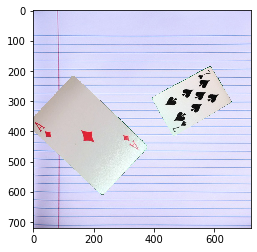

In [53]:
# display the image
plt.imshow(img_np)
plt.show()

In [54]:
img_tensor=torch.from_numpy(img_np)
print(img_tensor.shape)
# torch with the same shape

torch.Size([720, 720, 3])


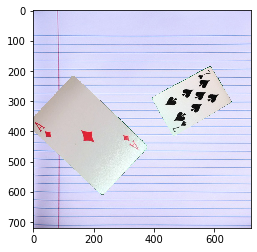

In [55]:
# display the image
plt.imshow(img_tensor)
plt.show()


In [56]:
out=img_tensor.permute(2,0,1)   # Pytorch: Channelxheightxwidth =CxHxW
print(out.shape)
# PyTorch image: (3, H, W)

torch.Size([3, 720, 720])


In [57]:
batch_size = 4
batch = torch.zeros(batch_size, 3, 96, 96, dtype=torch.uint8)
import os
data_dir = '../torch_tutorial/data/student_faces/'
filenames = [name for name in os.listdir(data_dir) if os.path.splitext(name)[-1] == '.jpg']
for i, filename in enumerate(filenames):
    img_arr = imageio.imread(os.path.join(data_dir, filename))
    img_t = torch.from_numpy(img_arr)
    img_t = img_t.permute(2, 0, 1)
    img_t = img_t[:3]
    batch[i] = img_t
    
print(batch.shape)
# display the image
# plt.imshow(batch[1].permute(1,2,0))
# plt.show()

torch.Size([4, 3, 96, 96])


In [58]:
import csv

In [59]:
import numpy as np

In [60]:
xy_path = "c:/machine_learning/mnist_test.csv"
xy_numpy = np.loadtxt(xy_path, delimiter=",")
xy_t=torch.tensor(xy_numpy)

In [61]:
print(xy_t.shape)
xy_t

torch.Size([10000, 785])


tensor([[7., 0., 0.,  ..., 0., 0., 0.],
        [2., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [4., 0., 0.,  ..., 0., 0., 0.],
        [5., 0., 0.,  ..., 0., 0., 0.],
        [6., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64)

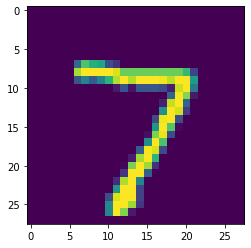

In [62]:
# display the image
plt.imshow(xy_t[0][1:].view(28,28))
plt.show()

In [63]:
wine_path = "../torch_tutorial/data/winequality-white.csv"
wine_numpy = np.loadtxt(wine_path, delimiter=";", skiprows=1)
wine_tensor=torch.from_numpy(wine_numpy)
print(wine_tensor.shape)
wine_tensor


torch.Size([4898, 12])


tensor([[ 7.0000,  0.2700,  0.3600,  ...,  0.4500,  8.8000,  6.0000],
        [ 6.3000,  0.3000,  0.3400,  ...,  0.4900,  9.5000,  6.0000],
        [ 8.1000,  0.2800,  0.4000,  ...,  0.4400, 10.1000,  6.0000],
        ...,
        [ 6.5000,  0.2400,  0.1900,  ...,  0.4600,  9.4000,  6.0000],
        [ 5.5000,  0.2900,  0.3000,  ...,  0.3800, 12.8000,  7.0000],
        [ 6.0000,  0.2100,  0.3800,  ...,  0.3200, 11.8000,  6.0000]],
       dtype=torch.float64)

In [64]:
col_list =next(csv.reader(open(wine_path), delimiter=';'))

col_list


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [65]:
# split the data into input and label
input_data=wine_tensor[:,:-1]
label=wine_tensor[:, -1].long()
print(label)


tensor([6, 6, 6,  ..., 6, 7, 6])


In [66]:
# normalize each feature
input_data_mean=torch.mean(input_data, 0)
input_data_var=torch.var(input_data,0)
input_data_normalized = (input_data - input_data_mean) / torch.sqrt(input_data_var)


In [67]:
# generate onehot for label tensor
label_examples=torch.tensor([0,1,2,3,4,5,6,7,8,9,3,4,9,1])
label_onehot = torch.zeros(label_examples.shape[0], 10)
label_onehot.scatter_(1, label_examples.unsqueeze(1), 1.0)
label_onehot

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [68]:
y = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
x = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]

# training dataset

In [69]:
x=torch.tensor([12.1101, 5.5277, 8.5186, 7.0032, 5.8598, 8.3829, 7.4764, 8.5781, 6.4862, 5.0546, 5.7107, 11.164, 5.734, 8.4084, 5.6407, 5.3794, 6.3654, 5.1301, 6.4296, 7.0708])

In [70]:
y=torch.tensor([10.592, 9.1302, 13.662, 11.854, 6.8233, 11.886, 4.3483, 12, 6.5987, 3.8166,3.2522, 15.505, 3.1551, 7.2258, 1.71618, 3.5129, 5.3048, 0.56077, 3.6518, 5.3893]) 

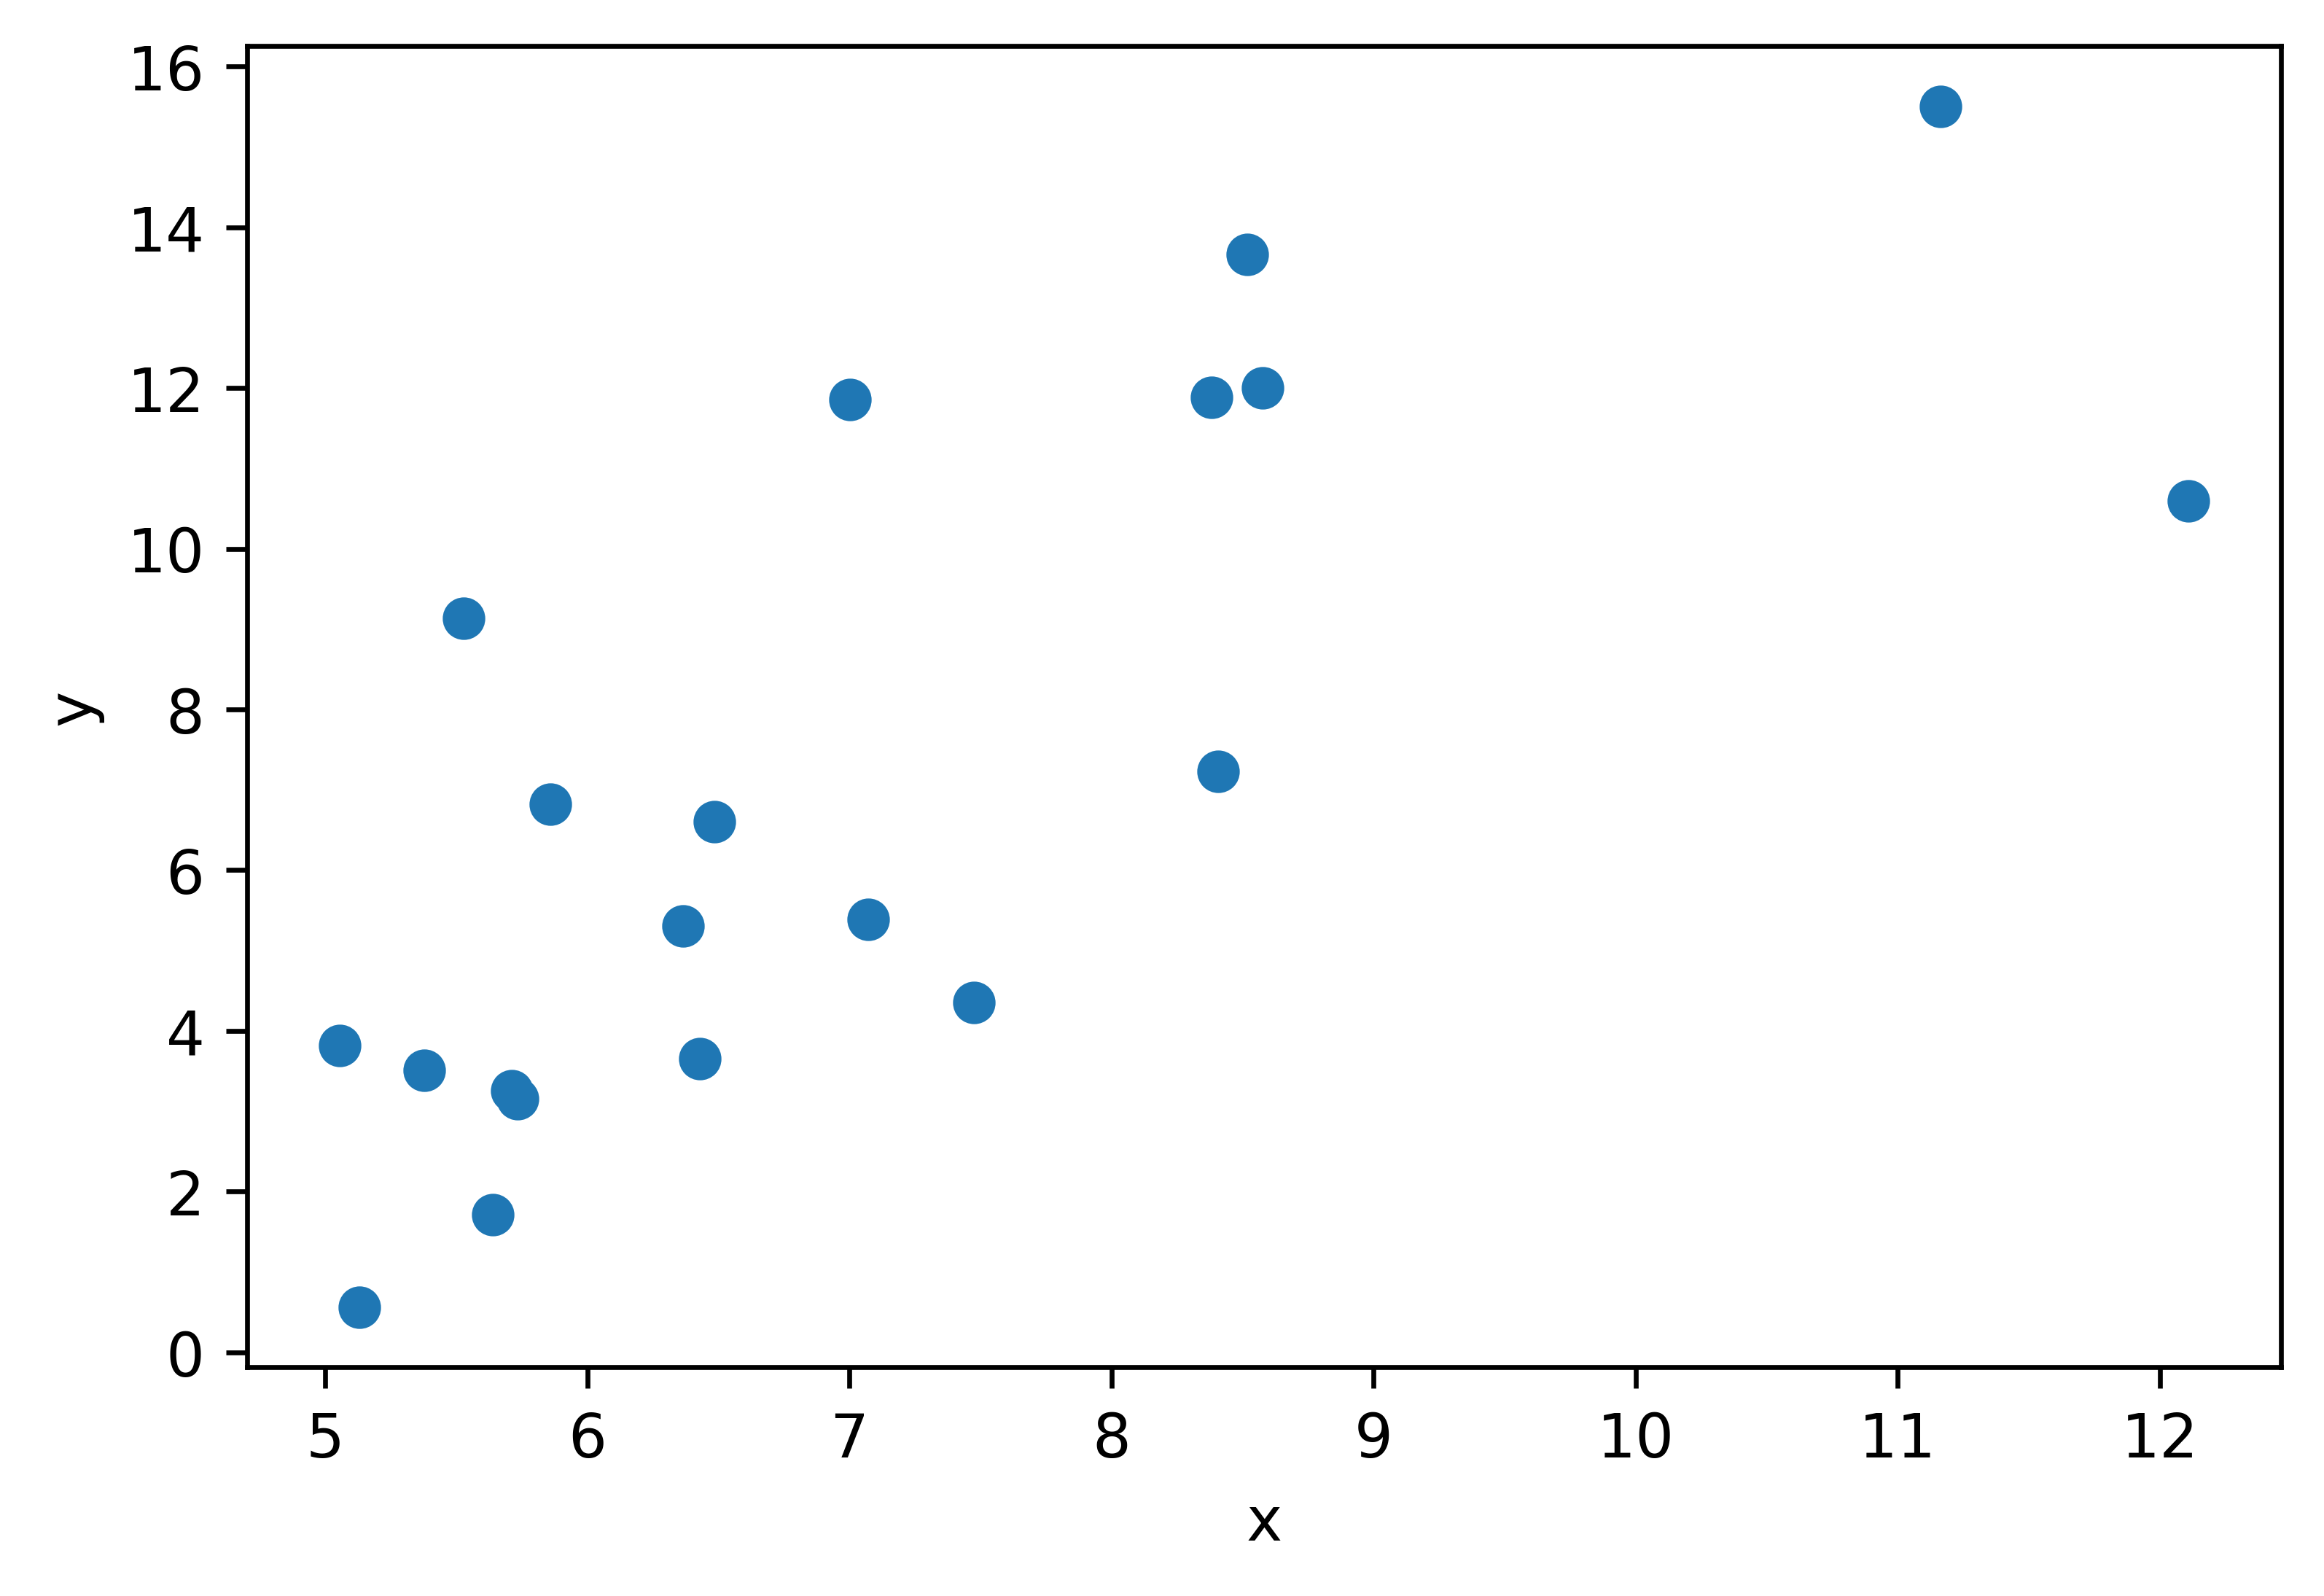

In [71]:
from matplotlib import pyplot as plt
fig = plt.figure(dpi=600)
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x.numpy(), y.numpy(), 'o')
plt.show()

In [72]:
# 1) define the linear model
def model_linear(x,w,b):
    y=w*x+b
    return y

In [73]:
# 2) define the loss function
def loss_fn(y, label):
    se=(y-label)**2
    mse=se.mean()
    return mse

In [74]:
# 3) define the gradient
def grad_fn(x,y,w,b):
    y_pred=model_linear(x,w,b)
    dw=2.0*(y_pred-y)*x/y.size(0)
    db=2.0*(y_pred-y)/y.size(0)
    return torch.stack([dw.sum(),db.sum()])


In [75]:
# 4) define the training loop
def training_loop(n_epochs, learning_rate, params, x, y):
    loss_tensor=torch.zeros(n_epochs)
    for epoch in range(1, n_epochs+1):
        w,b=params
        y_pred=model_linear(x,w,b)
        loss=loss_fn(y_pred,y)
        grad=grad_fn(x,y,w,b)
        params=params-learning_rate*grad
        print('Epoch %d, Loss %f' % (epoch, float(loss))) 
        loss_tensor[epoch-1]=loss
    return params, loss_tensor

In [76]:
params, loss_tensor= training_loop(
    n_epochs = 100,
    learning_rate = 0.002,
    params =torch.tensor([0.0,0.0]),
    x=x,
    y=y) 


Epoch 1, Loss 66.542000
Epoch 2, Loss 44.155342
Epoch 3, Loss 30.527868
Epoch 4, Loss 22.232265
Epoch 5, Loss 17.182270
Epoch 6, Loss 14.107924
Epoch 7, Loss 12.236194
Epoch 8, Loss 11.096518
Epoch 9, Loss 10.402459
Epoch 10, Loss 9.979648
Epoch 11, Loss 9.721959
Epoch 12, Loss 9.564776
Epoch 13, Loss 9.468776
Epoch 14, Loss 9.410021
Epoch 15, Loss 9.373936
Epoch 16, Loss 9.351648
Epoch 17, Loss 9.337761
Epoch 18, Loss 9.328989
Epoch 19, Loss 9.323332
Epoch 20, Loss 9.319568
Epoch 21, Loss 9.316957
Epoch 22, Loss 9.315049
Epoch 23, Loss 9.313570
Epoch 24, Loss 9.312352
Epoch 25, Loss 9.311293
Epoch 26, Loss 9.310328
Epoch 27, Loss 9.309423
Epoch 28, Loss 9.308555
Epoch 29, Loss 9.307710
Epoch 30, Loss 9.306875
Epoch 31, Loss 9.306052
Epoch 32, Loss 9.305235
Epoch 33, Loss 9.304417
Epoch 34, Loss 9.303606
Epoch 35, Loss 9.302794
Epoch 36, Loss 9.301983
Epoch 37, Loss 9.301173
Epoch 38, Loss 9.300364
Epoch 39, Loss 9.299556
Epoch 40, Loss 9.298748
Epoch 41, Loss 9.297941
Epoch 42, Loss 9

In [77]:
params

tensor([1.0282, 0.0075])

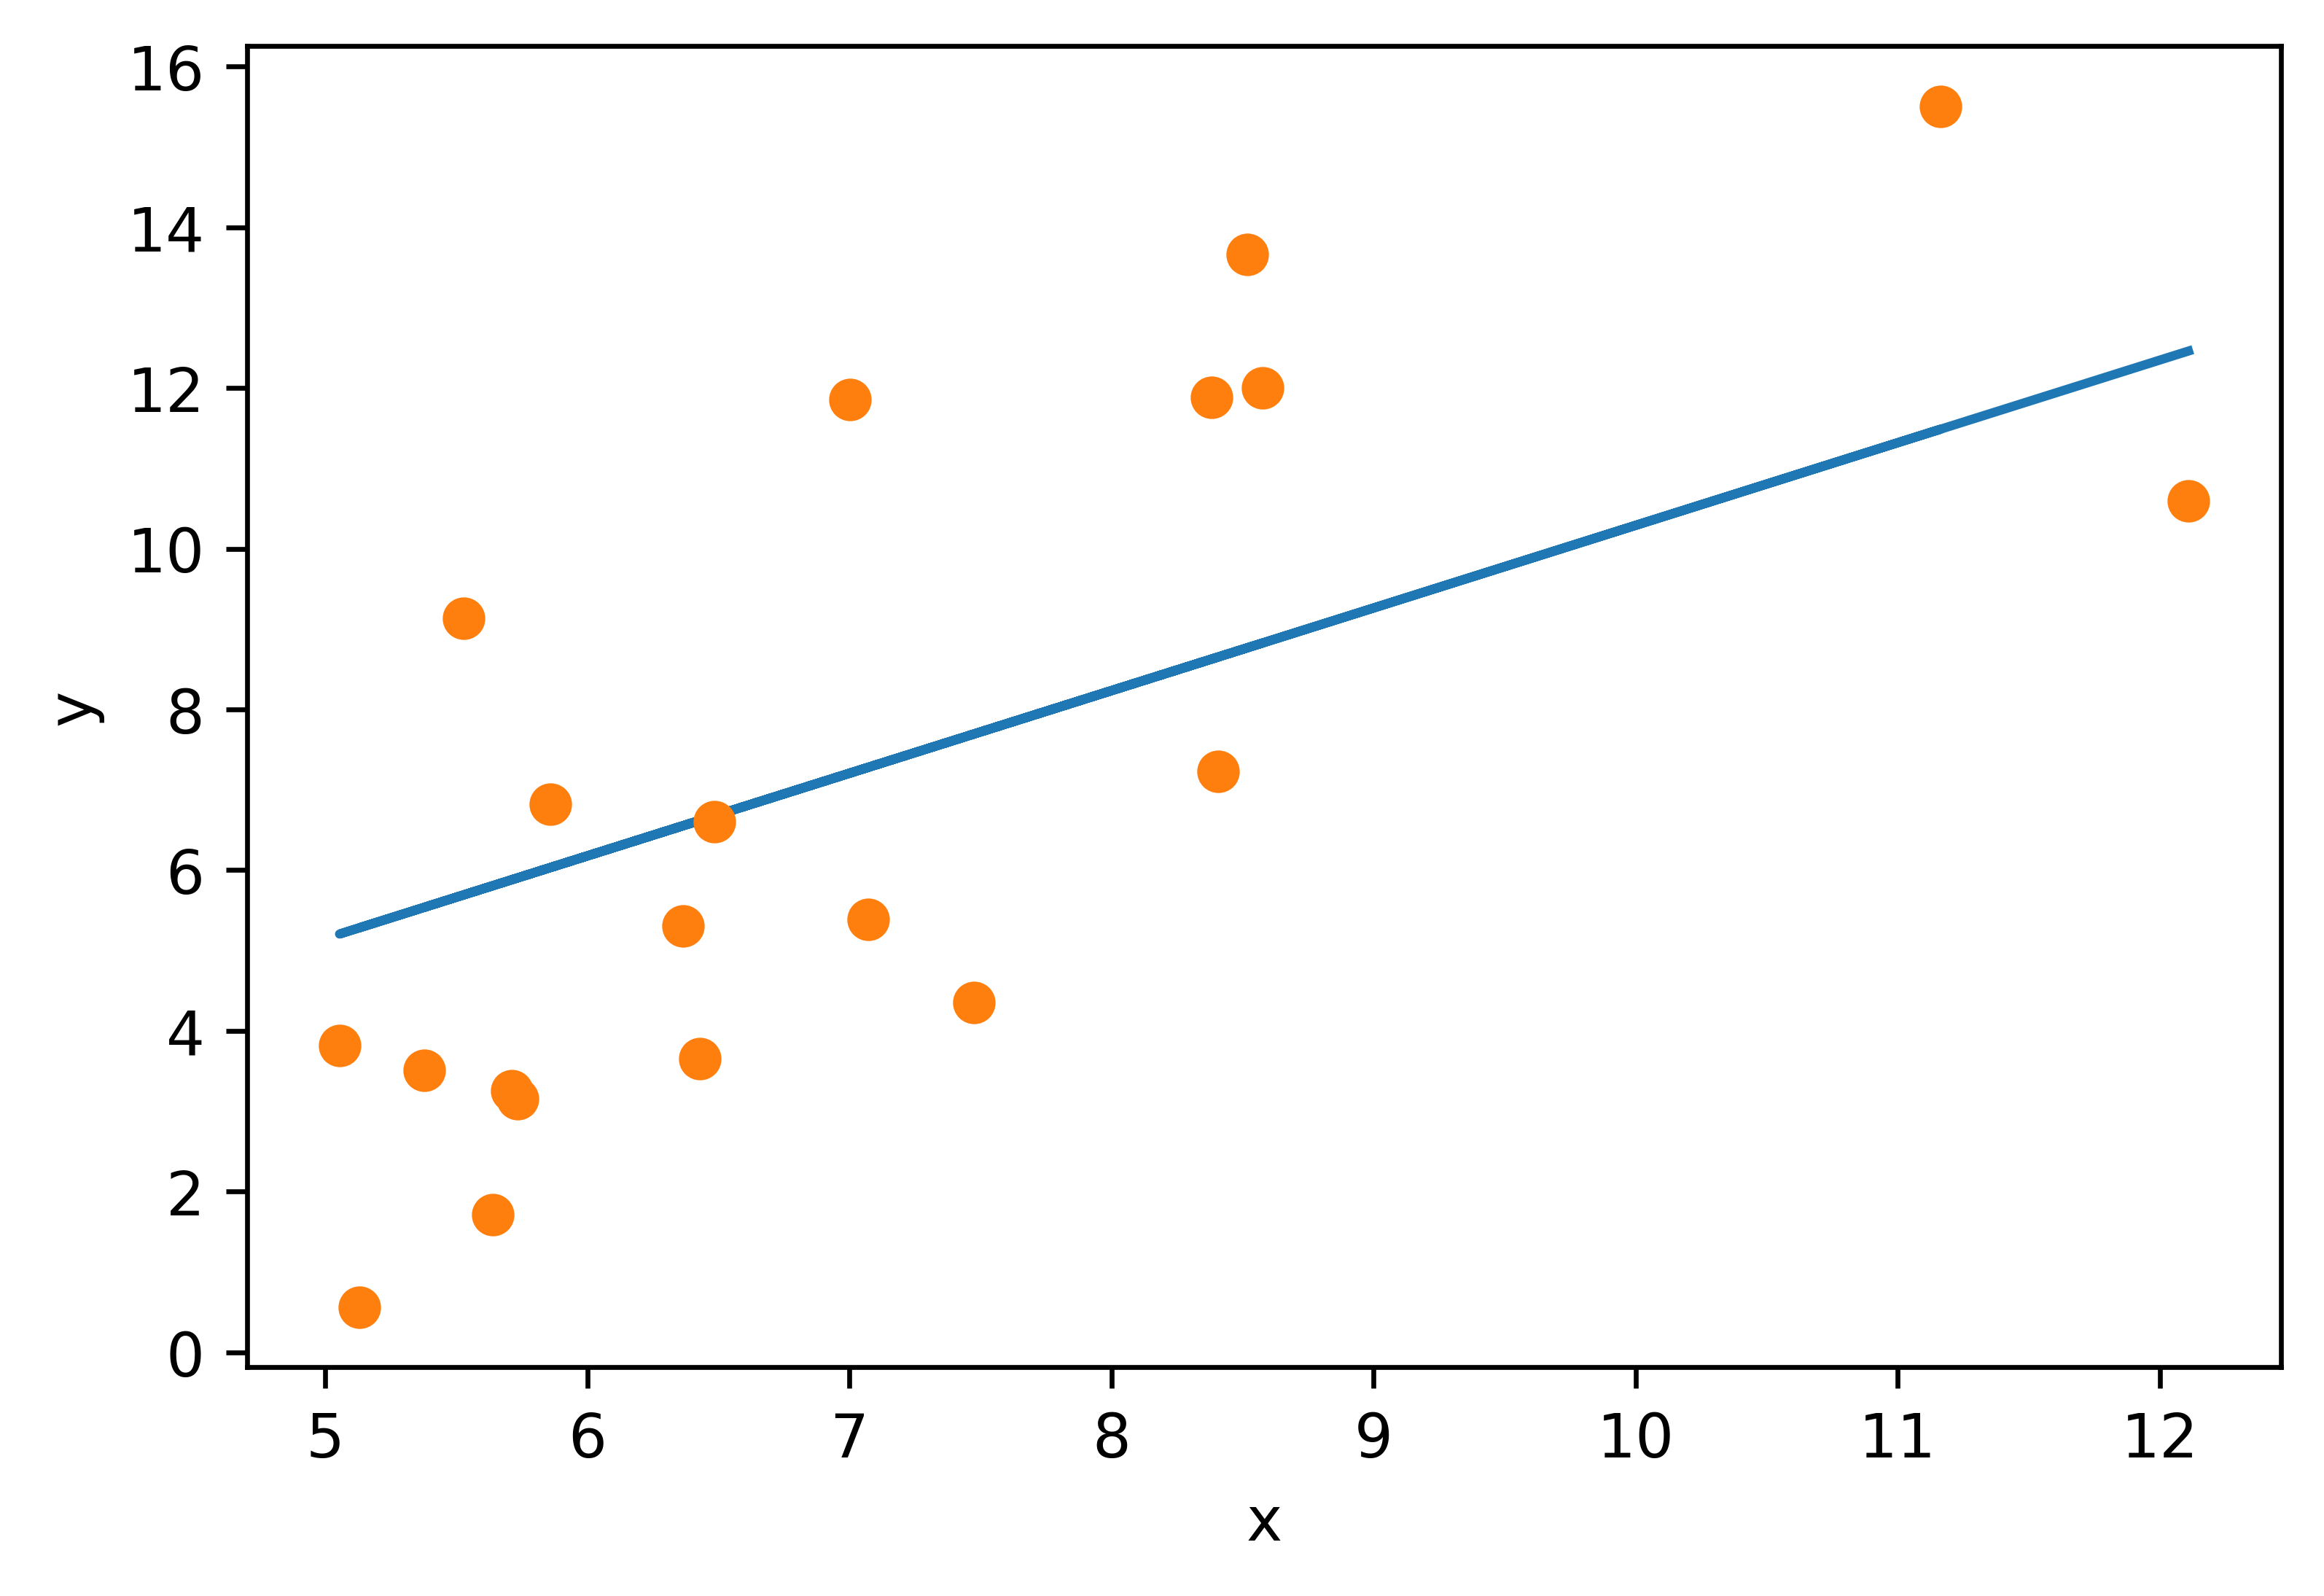

In [78]:
fig = plt.figure(dpi=600)
pred=model_linear(x,params[0],params[1])
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x.numpy(), pred.detach().numpy())
plt.plot(x.numpy(), y.numpy(), 'o')

In [79]:
pred.shape

torch.Size([20])

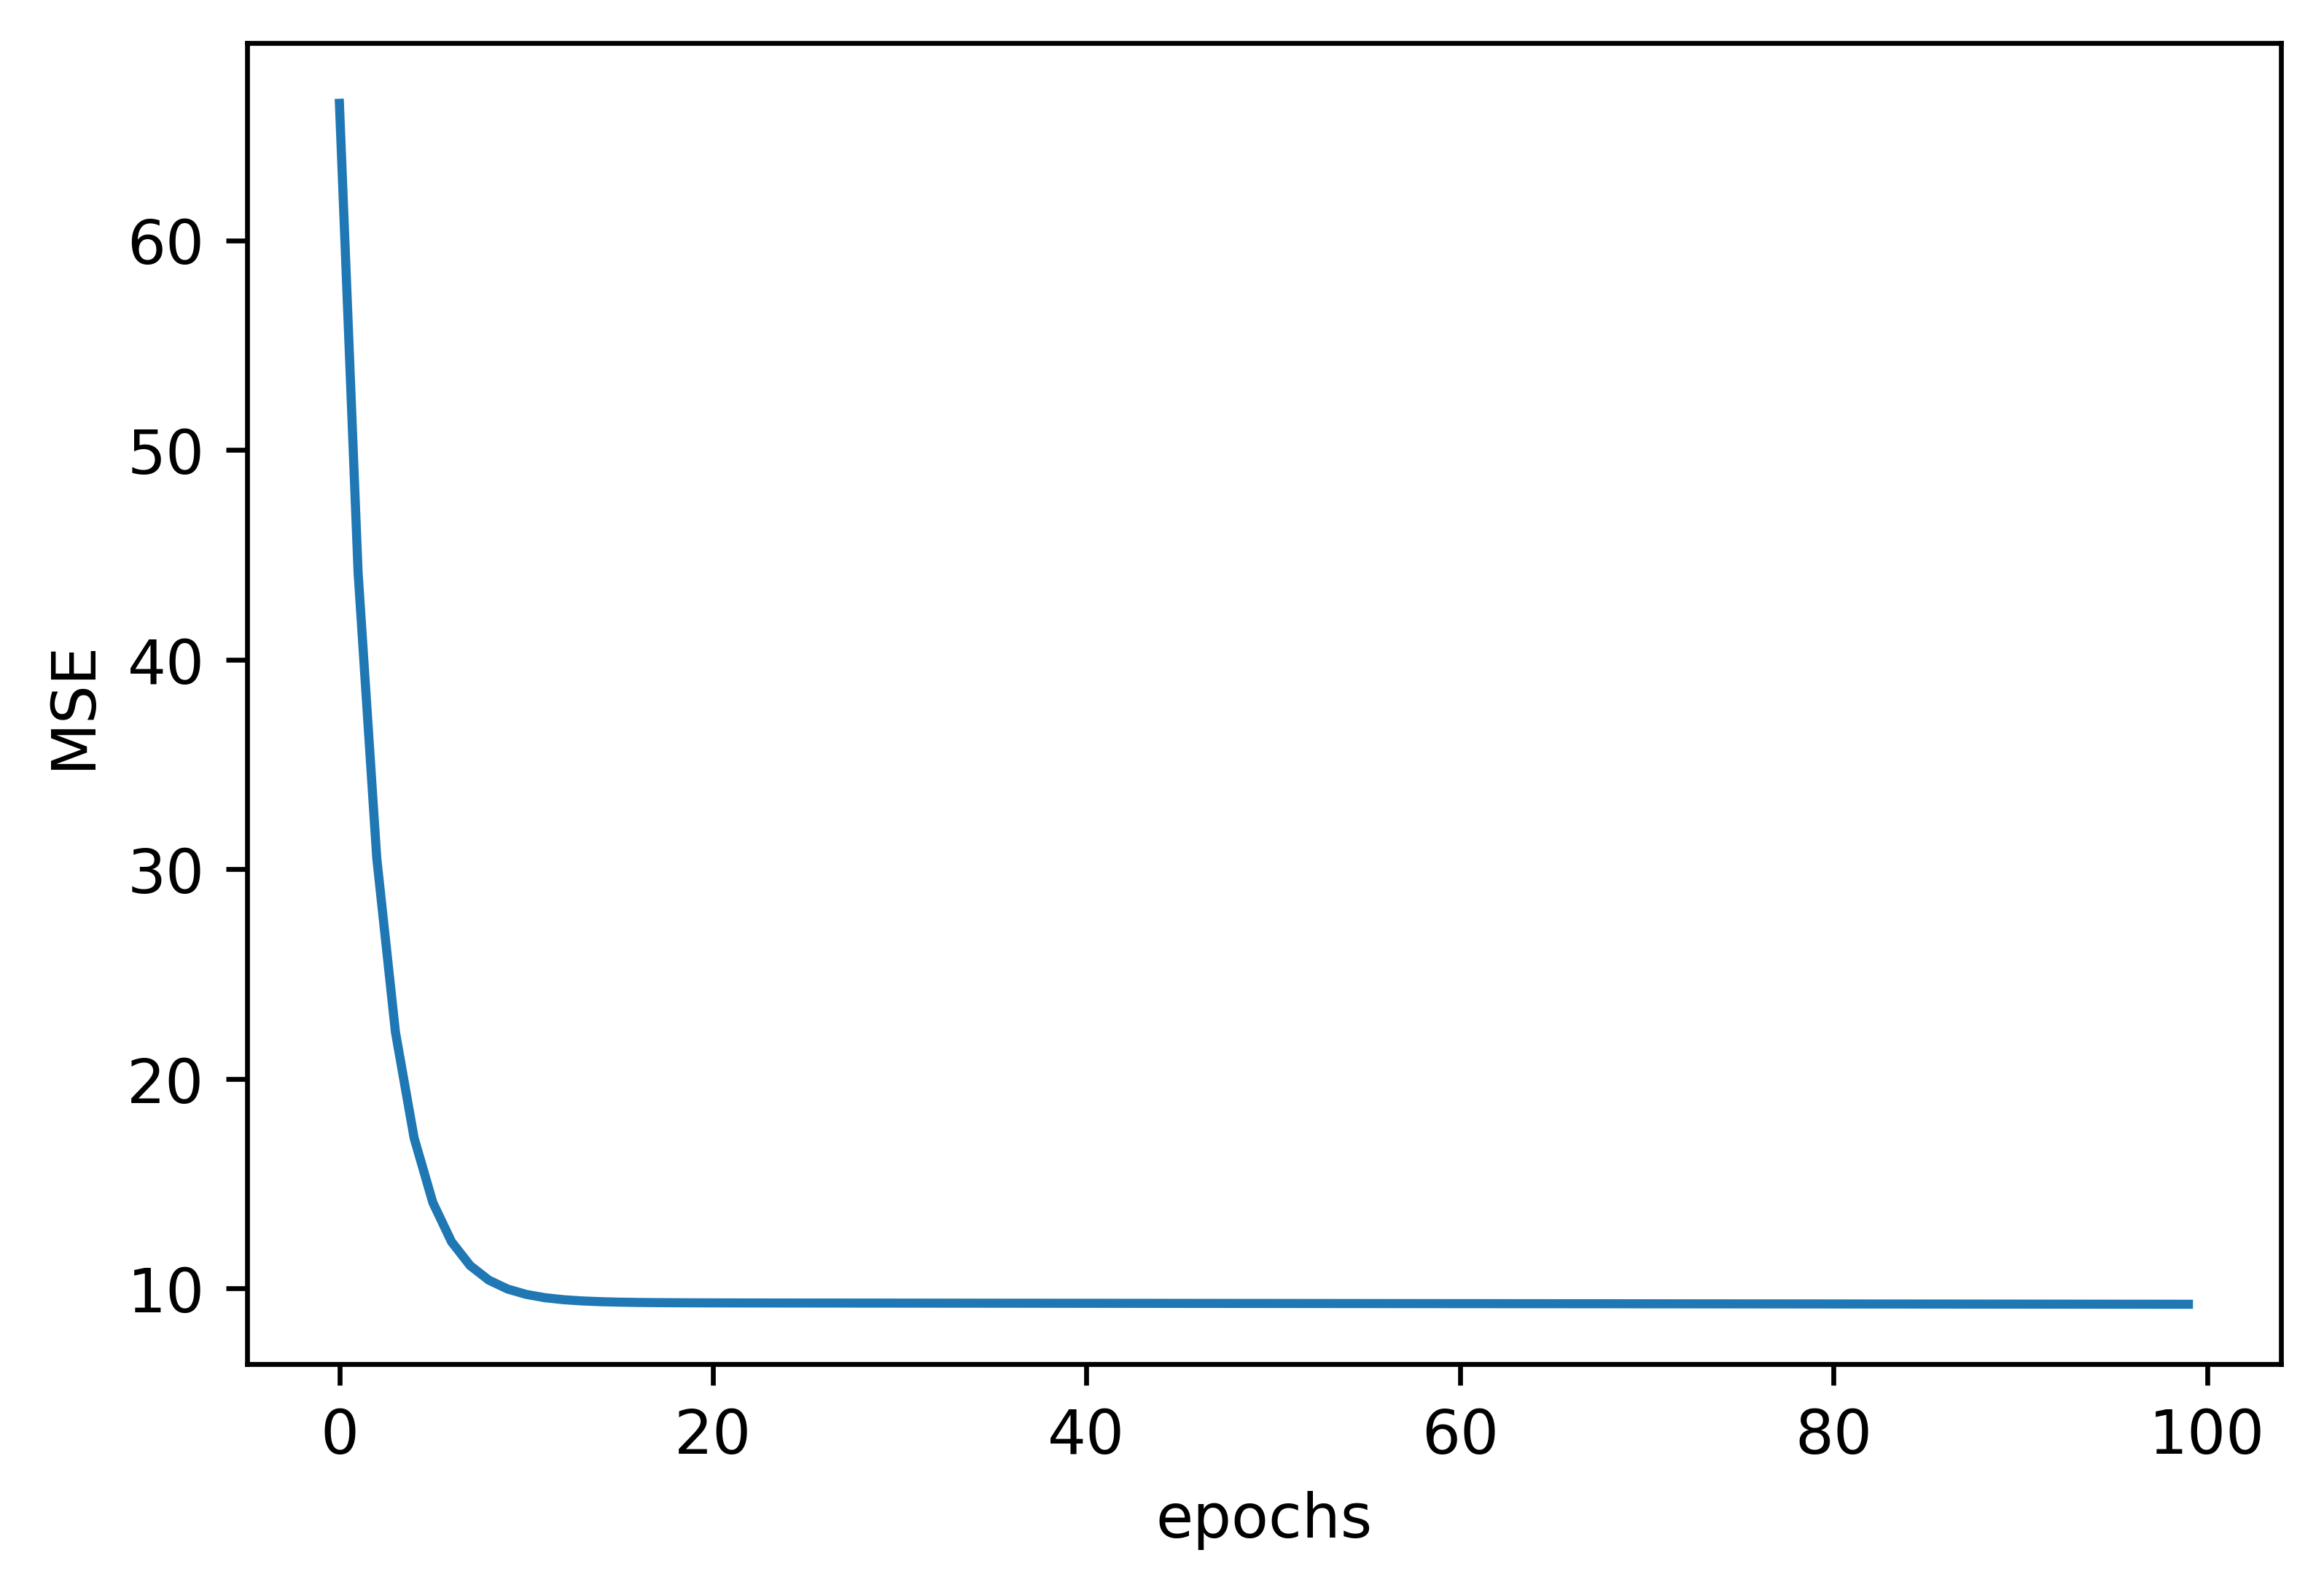

In [80]:
fig = plt.figure(dpi=600)
plt.xlabel("epochs")
plt.ylabel("MSE")
plt.plot(loss_tensor.detach().numpy())

In [81]:
#params.grad.zero_()
params.grad is None
#params.grad

True

comments: using autograd, don't need to derive the gradient equation

In [82]:
params = torch.tensor([1.0, 0.0], requires_grad=True)


In [83]:
y_pred=model_linear(x,params[0], params[1])           #forward propagation

In [84]:
loss=loss_fn(y_pred,y)           #loss computation

In [85]:
loss.backward()           # call .backward() for autograd

In [86]:
params.grad # dlss/dw, dloss/db

tensor([-3.2338,  0.2046])

In [87]:
y_pred=model_linear(x,params[0], params[1])           #forward propagation
loss=loss_fn(y_pred,y)           #loss computation
loss.backward()           # call .backward() for autograd
params.grad             # display gradient values


tensor([-6.4676,  0.4091])

In [88]:
if params.grad is not None:
    params.grad.zero_()

In [89]:
params

tensor([1., 0.], requires_grad=True)

In [90]:
params.grad

tensor([0., 0.])

In [91]:
y_pred=model_linear(x,params[0], params[1])           #forward propagation
loss=loss_fn(y_pred,y)           #loss computation
loss.backward()           # call .backward() for autograd
params.grad             # display gradient values


tensor([-3.2338,  0.2046])

In [92]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
def training_loop_autograd(n_epochs, learning_rate, params, x, y):
    loss_tensor=torch.zeros(n_epochs)
    for epoch in range(1, n_epochs+1):
        if params.grad is not None:
            params.grad.zero_()
        w,b=params
        y_pred=model_linear(x,w,b)
        loss=loss_fn(y_pred,y)
        loss.backward()
        
        with torch.no_grad():                        # no grad computation involved
            params -= learning_rate * params.grad
        
        #params=params-learning_rate*grad
        print('Epoch %d, Loss %f' % (epoch, float(loss))) 
        loss_tensor[epoch-1]=loss
    return params, loss_tensor


In [93]:
params, loss_tensor= training_loop_autograd(
    n_epochs = 100,
    learning_rate = 0.002,
    params =torch.tensor([0.0,0.0], requires_grad=True),
    x=x,
    y=y)


Epoch 1, Loss 66.542000
Epoch 2, Loss 44.155342
Epoch 3, Loss 30.527868
Epoch 4, Loss 22.232265
Epoch 5, Loss 17.182270
Epoch 6, Loss 14.107924
Epoch 7, Loss 12.236194
Epoch 8, Loss 11.096518
Epoch 9, Loss 10.402457
Epoch 10, Loss 9.979648
Epoch 11, Loss 9.721957
Epoch 12, Loss 9.564775
Epoch 13, Loss 9.468777
Epoch 14, Loss 9.410021
Epoch 15, Loss 9.373935
Epoch 16, Loss 9.351648
Epoch 17, Loss 9.337763
Epoch 18, Loss 9.328989
Epoch 19, Loss 9.323332
Epoch 20, Loss 9.319568
Epoch 21, Loss 9.316957
Epoch 22, Loss 9.315049
Epoch 23, Loss 9.313570
Epoch 24, Loss 9.312352
Epoch 25, Loss 9.311293
Epoch 26, Loss 9.310328
Epoch 27, Loss 9.309423
Epoch 28, Loss 9.308555
Epoch 29, Loss 9.307710
Epoch 30, Loss 9.306875
Epoch 31, Loss 9.306052
Epoch 32, Loss 9.305235
Epoch 33, Loss 9.304417
Epoch 34, Loss 9.303606
Epoch 35, Loss 9.302794
Epoch 36, Loss 9.301983
Epoch 37, Loss 9.301173
Epoch 38, Loss 9.300364
Epoch 39, Loss 9.299556
Epoch 40, Loss 9.298748
Epoch 41, Loss 9.297941
Epoch 42, Loss 9

In [94]:
params

tensor([1.0282, 0.0075], requires_grad=True)

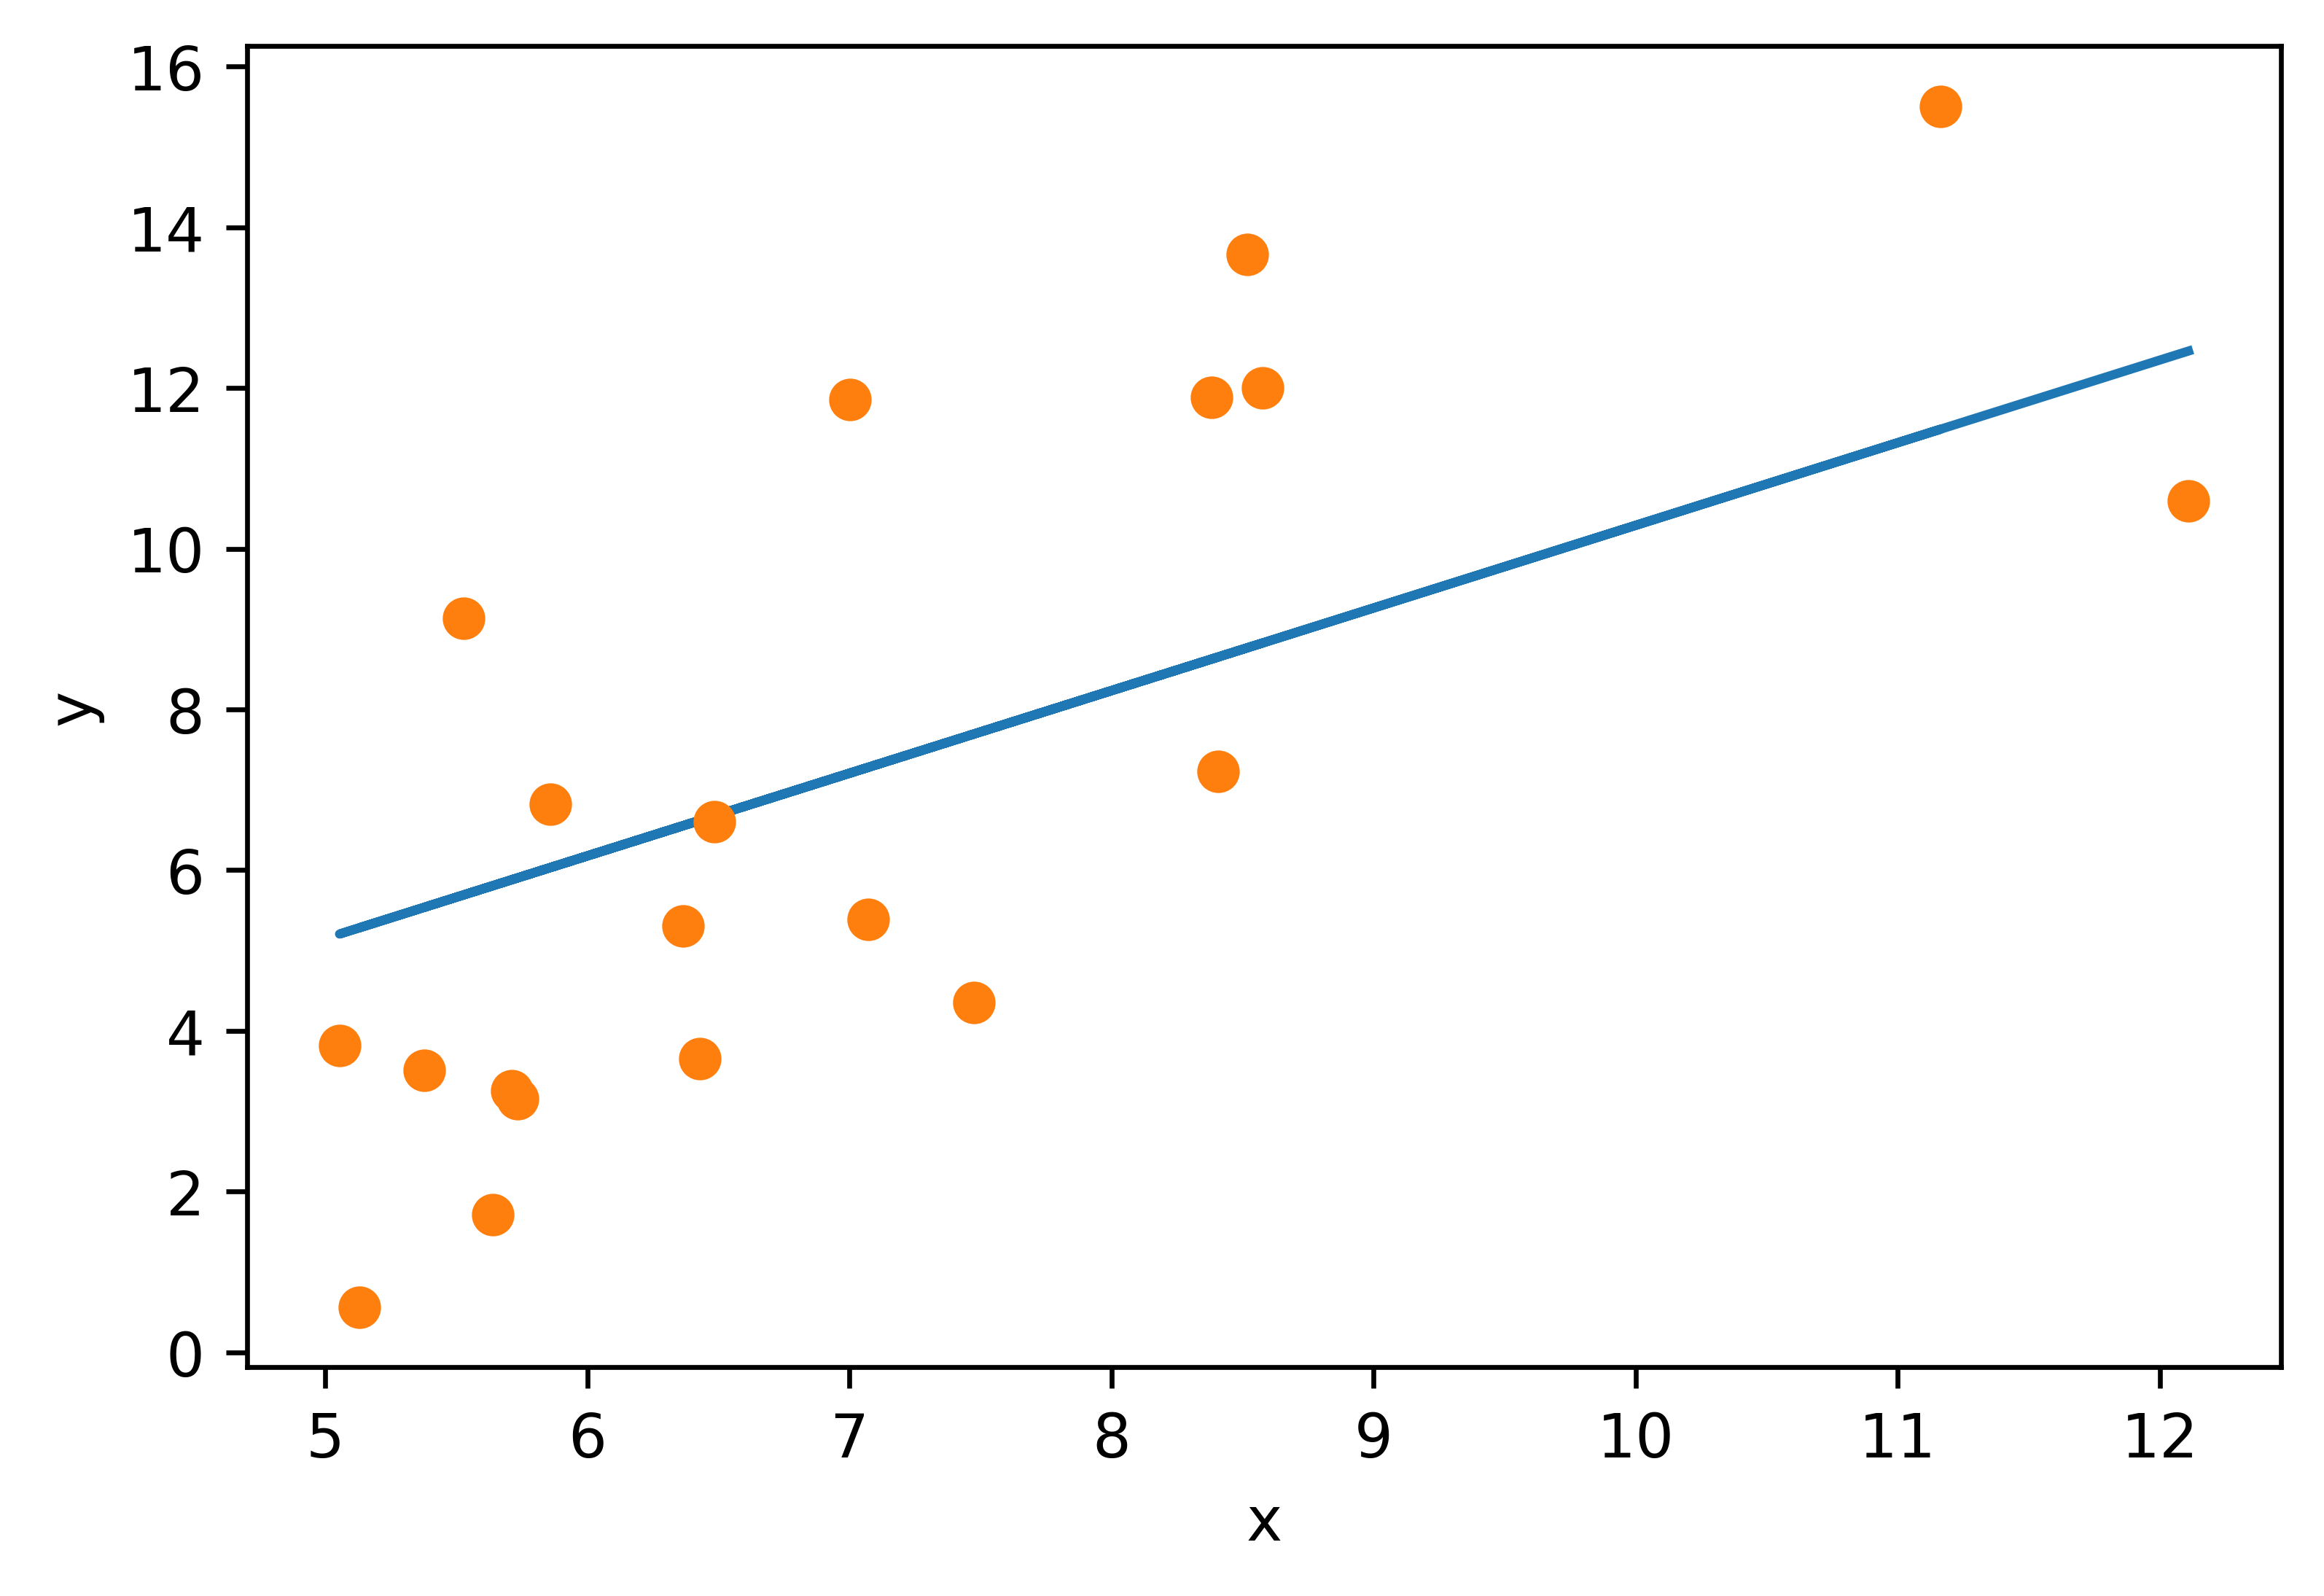

In [95]:
fig = plt.figure(dpi=600)
pred=model_linear(x,params[0],params[1])
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x.numpy(), pred.detach().numpy())
plt.plot(x.numpy(), y.numpy(), 'o')

In [96]:
import torch.optim as optim
dir(optim)

['ASGD',
 'Adadelta',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'Optimizer',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'lr_scheduler']

In [97]:
params = torch.tensor([0.0,0.0], requires_grad=True)
learning_rate=0.002
my_optimizer = optim.SGD([params], lr=learning_rate)   # construct an optimizer 
y_pred=model_linear(x,params[0], params[1])           #forward propagation
loss=loss_fn(y_pred,y)           #loss computation
my_optimizer.zero_grad()    # zero grad
loss.backward()           # call .backward() for autograd
my_optimizer.step()     # one step params update
params.grad             # display gradient values

tensor([-111.2624,  -13.9985])

In [98]:
params

tensor([0.2225, 0.0280], requires_grad=True)

In [99]:
#params = torch.tensor([0.0,0.0], requires_grad=True)
def training_loop_autograd_optim(optimizer, n_epochs, params, x, y):
    loss_tensor=torch.zeros(n_epochs)
    for epoch in range(1, n_epochs+1):
        w,b=params                  # forward path
        y_pred=model_linear(x,w,b)
        loss=loss_fn(y_pred,y)      # loss
        optimizer.zero_grad()       # zero grad
        loss.backward()             # calculate grad by autograd
        optimizer.step()            # update params by optimizer
         
        print('Epoch %d, Loss %f' % (epoch, float(loss))) 
        loss_tensor[epoch-1]=loss
    return params, loss_tensor


In [100]:
params = torch.tensor([0.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.RMSprop([params], lr=learning_rate)
params, loss_tensor = training_loop_autograd_optim(
n_epochs = 100,
optimizer = optimizer,
params = params,
x = x,
y = y)

Epoch 1, Loss 66.542000
Epoch 2, Loss 54.708076
Epoch 3, Loss 47.589836
Epoch 4, Loss 42.430077
Epoch 5, Loss 38.394062
Epoch 6, Loss 35.101967
Epoch 7, Loss 32.344307
Epoch 8, Loss 29.991491
Epoch 9, Loss 27.956928
Epoch 10, Loss 26.179495
Epoch 11, Loss 24.614218
Epoch 12, Loss 23.226891
Epoch 13, Loss 21.990833
Epoch 14, Loss 20.884777
Epoch 15, Loss 19.891459
Epoch 16, Loss 18.996662
Epoch 17, Loss 18.188528
Epoch 18, Loss 17.457037
Epoch 19, Loss 16.793671
Epoch 20, Loss 16.191101
Epoch 21, Loss 15.642981
Epoch 22, Loss 15.143784
Epoch 23, Loss 14.688677
Epoch 24, Loss 14.273384
Epoch 25, Loss 13.894139
Epoch 26, Loss 13.547572
Epoch 27, Loss 13.230696
Epoch 28, Loss 12.940826
Epoch 29, Loss 12.675556
Epoch 30, Loss 12.432721
Epoch 31, Loss 12.210360
Epoch 32, Loss 12.006702
Epoch 33, Loss 11.820147
Epoch 34, Loss 11.649238
Epoch 35, Loss 11.492642
Epoch 36, Loss 11.349161
Epoch 37, Loss 11.217688
Epoch 38, Loss 11.097220
Epoch 39, Loss 10.986842
Epoch 40, Loss 10.885711
Epoch 41,

In [101]:
params

tensor([0.9209, 0.7387], requires_grad=True)

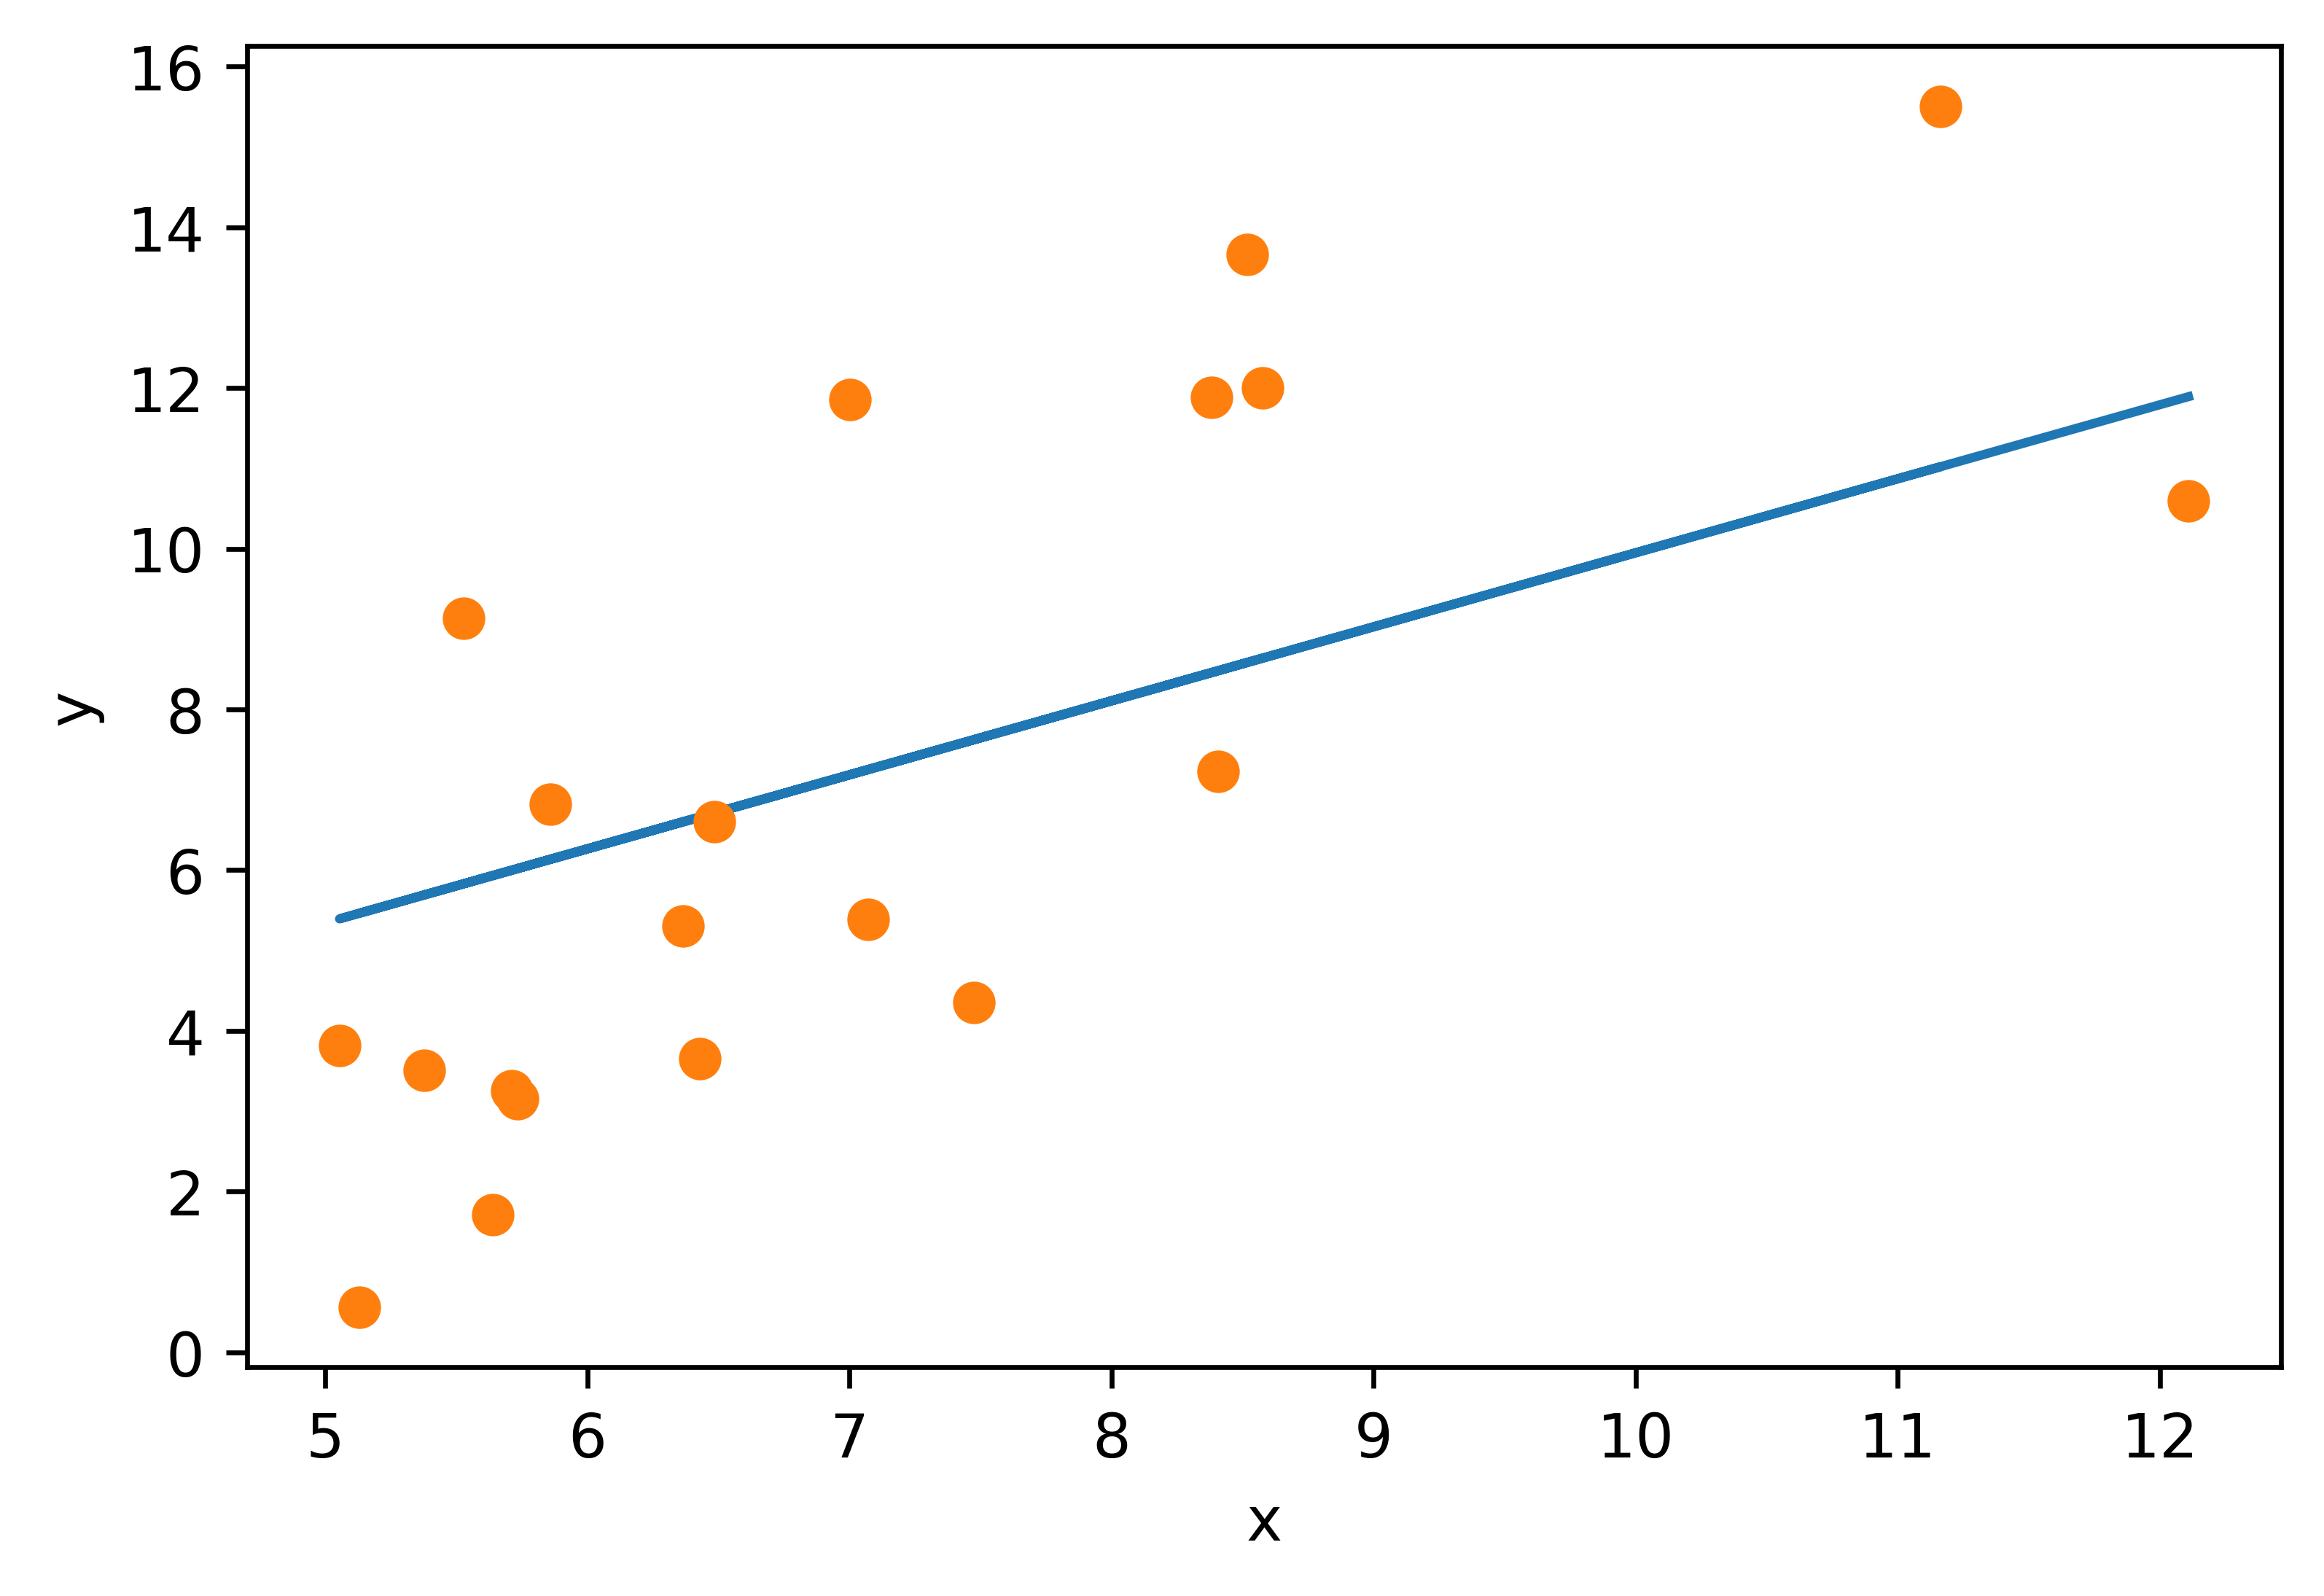

In [102]:
fig = plt.figure(dpi=600)
pred=model_linear(x,params[0],params[1])
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x.numpy(), pred.detach().numpy())
plt.plot(x.numpy(), y.numpy(), 'o')